In [1]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
sentences = [

# Cricket
"The batsman hit a powerful cover drive for four runs.",
"The bowler delivered a fast yorker that broke the stumps.",
"The team celebrated after winning the cricket match.",

# Cooking
"I added garlic and butter to the pan to prepare the pasta sauce.",
"The chef carefully baked the chocolate cake in the oven.",
"Fresh vegetables make the soup more delicious.",

# Cybersecurity
"Strong passwords help protect online accounts from hackers.",
"Cybersecurity experts monitor networks for suspicious activity.",
"Phishing emails try to trick users into revealing sensitive information.",
"Two-factor authentication adds an extra layer of security."
]

In [4]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [5]:
similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(similarity_matrix,
                             index=sentences,
                             columns=sentences)

similarity_df

,The batsman hit a powerful cover drive for four runs.,The bowler delivered a fast yorker that broke the stumps.,The team celebrated after winning the cricket match.,I added garlic and butter to the pan to prepare the pasta sauce.,The chef carefully baked the chocolate cake in the oven.,Fresh vegetables make the soup more delicious.,Strong passwords help protect online accounts from hackers.,Cybersecurity experts monitor networks for suspicious activity.,Phishing emails try to trick users into revealing sensitive information.,Two-factor authentication adds an extra layer of security.
The batsman hit a powerful cover drive for four runs.,1.000000,0.466643,0.341461,-0.011653,0.019363,0.024968,0.069649,-0.012820,0.019947,-0.035689
The bowler delivered a fast yorker that broke the stumps.,0.466643,1.000000,0.408419,0.030022,0.115633,0.068647,0.072073,0.051804,0.054586,-0.045591
The team celebrated after winning the cricket match.,0.341461,0.408419,1.000000,-0.015592,0.059893,0.057227,-0.038153,-0.061383,-0.002331,-0.048574
I added garlic and butter to the pan to prepare the pasta sauce.,-0.011653,0.030022,-0.015592,1.000000,0.291224,0.309047,-0.022859,0.051433,0.051314,0.003895
The chef carefully baked the chocolate cake in the oven.,0.019363,0.115633,0.059893,0.291224,1.000000,0.028392,-0.076677,0.016597,0.165680,-0.005399
Fresh vegetables make the soup more delicious.,0.024968,0.068647,0.057227,0.309047,0.028392,1.000000,0.041592,0.004774,-0.001548,0.046754
Strong passwords help protect online accounts from hackers.,0.069649,0.072073,-0.038153,-0.022859,-0.076677,0.041592,1.000000,0.262494,0.440660,0.460360
Cybersecurity experts monitor networks for suspicious activity.,-0.012820,0.051804,-0.061383,0.051433,0.016597,0.004774,0.262494,1.000000,0.256388,0.193876
Phishing emails try to trick users into revealing sensitive information.,0.019947,0.054586,-0.002331,0.051314,0.165680,-0.001548,0.440660,0.256388,1.000000,0.376744
Two-factor authentication adds an extra layer of security.,-0.035689,-0.045591,-0.048574,0.003895,-0.005399,0.046754,0.460360,0.193876,0.376744,1.000000


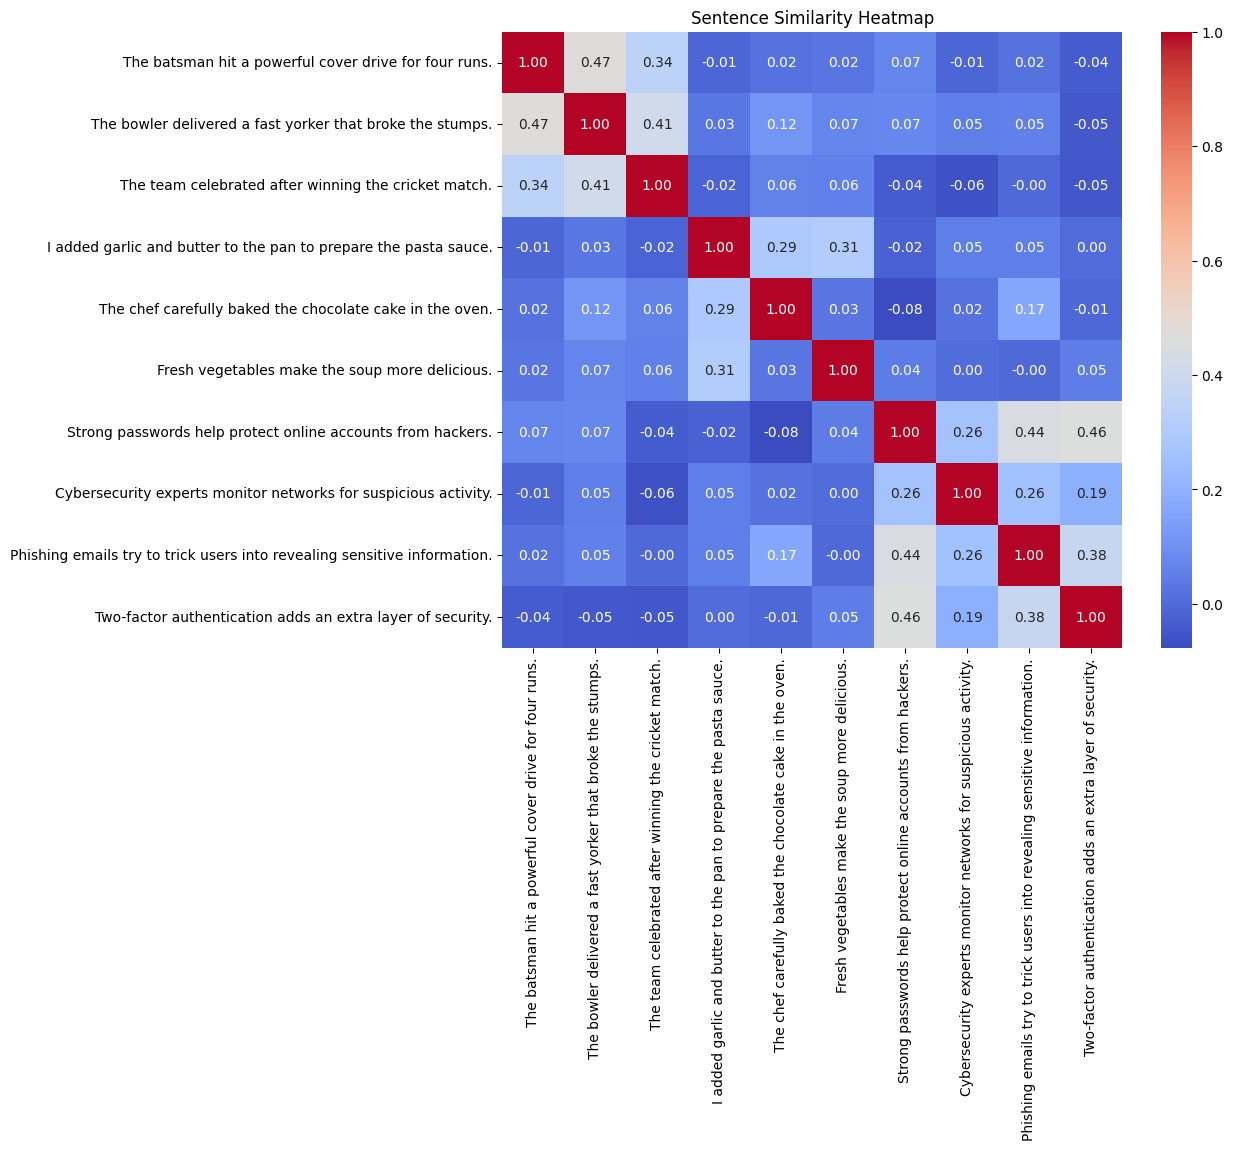

In [6]:
plt.figure(figsize=(10,8))

sns.heatmap(similarity_df,
            cmap="coolwarm",
            annot=True,
            fmt=".2f")

plt.title("Sentence Similarity Heatmap")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

In [8]:
import numpy as np

top_indices = np.argsort(scores)[::-1][:2]

print("Query:", query)
print()

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", round(scores[idx],3))
    print()

Query: The bowler took three wickets in one over

Sentence: The bowler delivered a fast yorker that broke the stumps.
Similarity Score: 0.611

Sentence: The batsman hit a powerful cover drive for four runs.
Similarity Score: 0.55

